<a href="https://colab.research.google.com/github/SilasDetering/SilasBA/blob/main/IndoorPositioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np
import math

# Google Drive mounten
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


höhendiverenz > Entfernung (1.06>0.961)
höhendiverenz > Entfernung (1.06>0.926)
höhendiverenz > Entfernung (1.06>0.86)
höhendiverenz > Entfernung (1.06>0.758)
höhendiverenz > Entfernung (1.06>0.691)
höhendiverenz > Entfernung (1.06>0.671)
höhendiverenz > Entfernung (1.06>0.777)
höhendiverenz > Entfernung (1.06>0.891)
höhendiverenz > Entfernung (1.06>0.809)
höhendiverenz > Entfernung (1.06>1.027)
höhendiverenz > Entfernung (1.06>0.757)
höhendiverenz > Entfernung (1.06>0.94)
höhendiverenz > Entfernung (1.06>0.963)
höhendiverenz > Entfernung (1.06>0.776)
höhendiverenz > Entfernung (1.06>0.85)
höhendiverenz > Entfernung (1.06>0.952)
höhendiverenz > Entfernung (1.06>0.829)
höhendiverenz > Entfernung (1.06>0.837)
höhendiverenz > Entfernung (1.06>0.86)
höhendiverenz > Entfernung (1.06>0.745)
höhendiverenz > Entfernung (1.06>0.978)
höhendiverenz > Entfernung (1.06>0.724)
höhendiverenz > Entfernung (1.06>0.782)
höhendiverenz > Entfernung (1.06>0.89)
höhendiverenz > Entfernung (1.06>0.842)
höhen

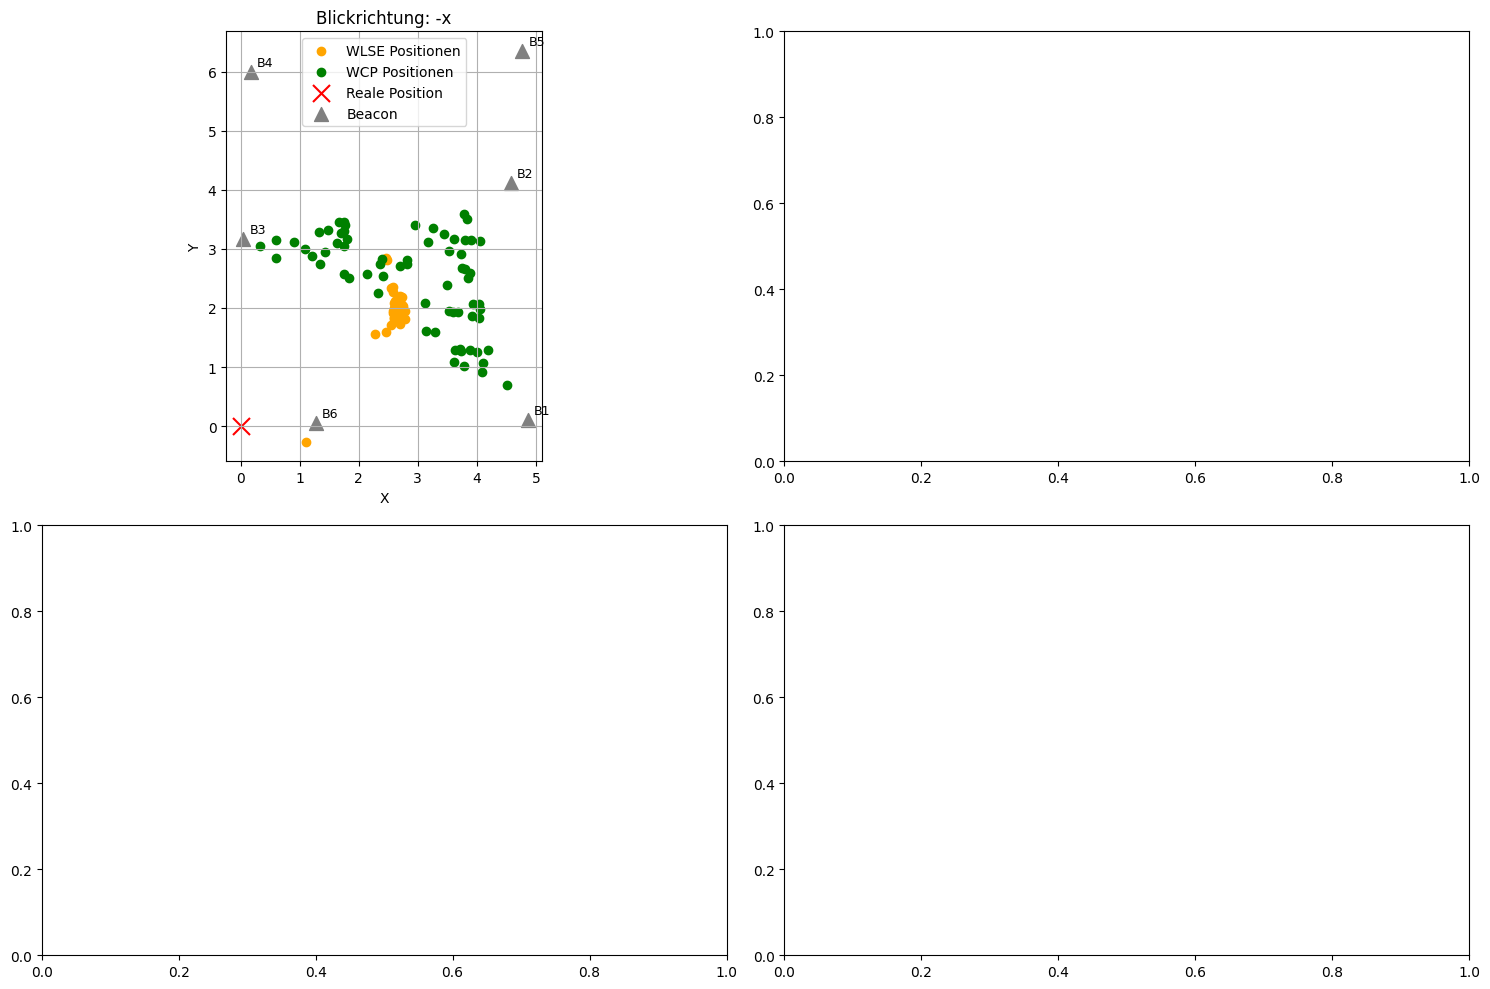

-x 90%
LSE:  3.437 m
WSE:  3.437 m
WCP:  4.733 m


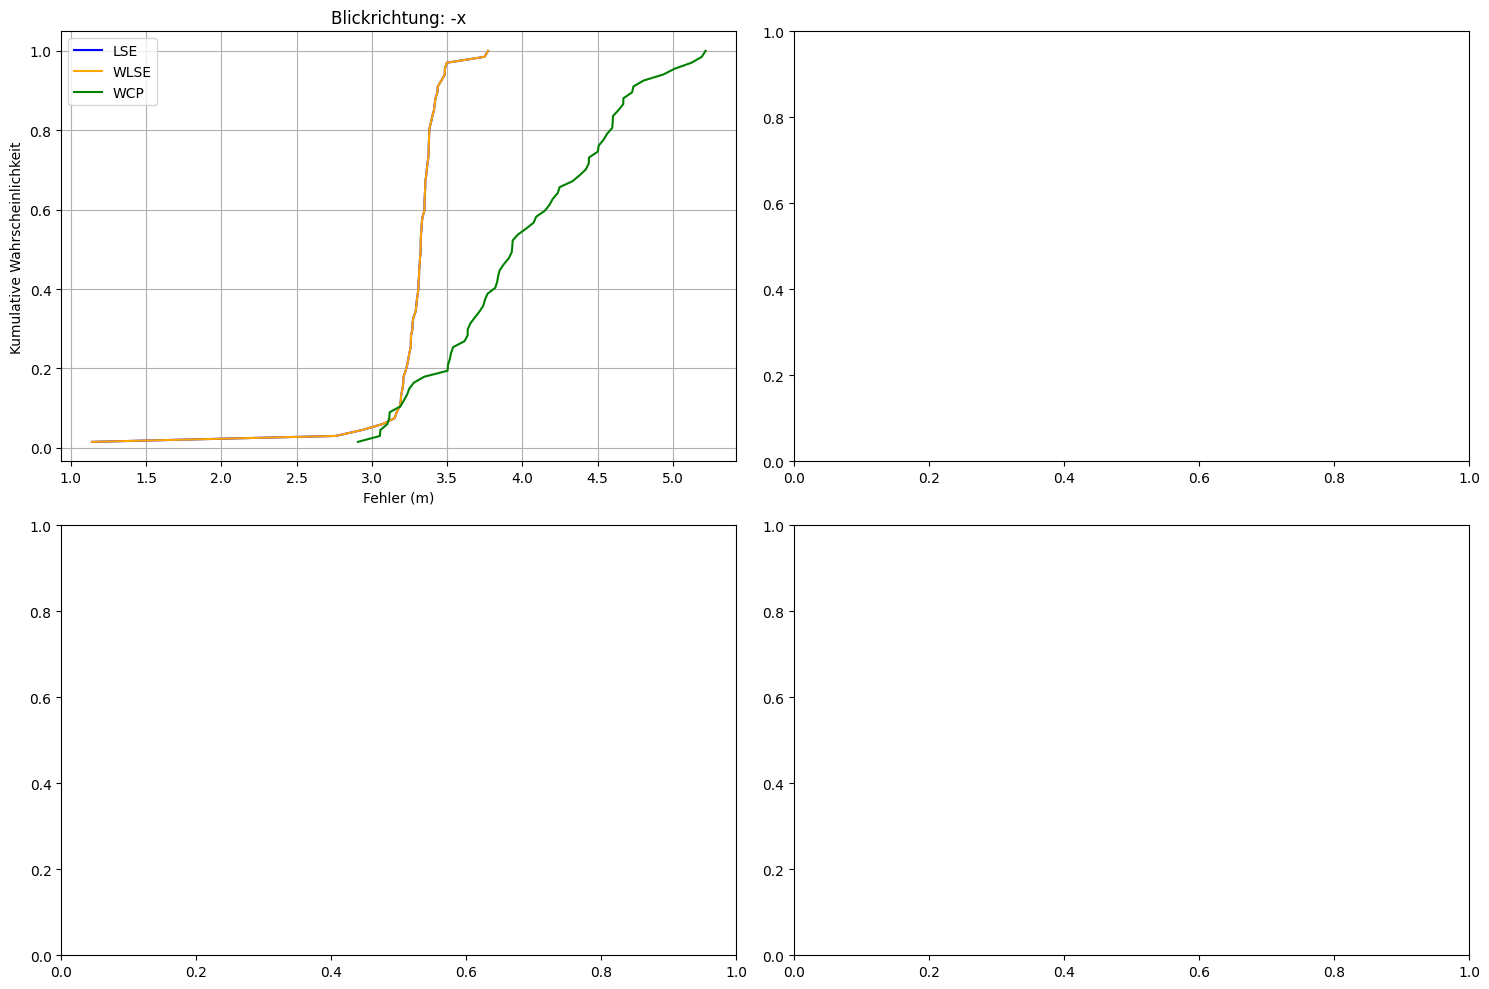

In [4]:
# PARAMETER
# ==============================================================================

# Messpunkt und Messdatum wählen
referenz = 4
date = 1402 # Tag + Monat

# Beacon filtern
excluded_beacons = {} # "B4","B5"
do_select_top_beacons = True
do_normalize_height = True

# RSSI Filter
slected_rssi_filter = "rssi_kalman" # "rssi_mean", "rssi_max"

# Beacons
beacons = {
    "B1": (4.86, 0.11, 0.36),
    "B2": (4.58, 4.12, 0.36),
    "B3": (0.05, 3.16, 1.06),
    "B4": (0.18, 6.00, 1.32),
    "B5": (4.77, 6.35, 0.56),
    "B6": (1.28, 0.06, 1.06),
}

# Refernezpunkte
referencePoints = {
    1: (1.50, 3.00, 1.10),
    2: (3.00, 0.75, 1.10),
    3: (3.50, 2.25, 1.10),
    4: (2.50, 4.00, 1.10),
    5: (0.75, 0.75, 1.10),
    6: (1.50, 5.00, 1.10),
    7: (3.50, 5.50, 1.10),
}

# Distance Path-Loss Values:
n = 2.20
A = -50.00

# Gewichtungen
weightDropoff_WLSE_default = 4.0
weightDropoff_WCP_default = 2.0

# Blickrichtungen
directions = ['-x', '+x', '-y', '+y']

# ==============================================================================

# Liest die Excel-Datei ein und filtert Beacons basierend auf den angegebenen Kriterien.
def read_excel(file_path):
    df = pd.read_excel(file_path, header=None, names=["id", "beacon", "rssi_kalman", "rssi_mean", "rssi_max"])
    df = df[~df['beacon'].str.contains("x:|y:|err:", na=False)]
    df.loc[:, "rssi_kalman"] = df["rssi_kalman"].astype(float)
    df.loc[:, "rssi_mean"] = df["rssi_mean"].astype(float)
    df.loc[:, "rssi_max"] = df["rssi_max"].astype(float)

    df.loc[:, 'beacon'] = df['beacon'].str.strip()

    # Filtere die Beacons, die ausgeschlossen werden sollen
    df = df[~df['beacon'].isin(excluded_beacons)]

    all_measurements = {}
    for _, row in df.iterrows():
        beacon_name = row["beacon"]

        if beacon_name in beacons:
            beacon_coords = beacons[beacon_name]

            if str(row["id"]) not in all_measurements:
                all_measurements[str(row["id"])] = {}

            all_measurements[str(row["id"])][beacon_coords] = row[slected_rssi_filter]
    return all_measurements


# Berechnet die Entfernung basierend auf dem RSSI-Wert unter Verwendung des Path Loss Modells.
def distancePathLossModel(rssi):
  rssi = round(rssi, 3)
  dist = 10 ** ((A - rssi) / (10 * n))
  return round(dist, 3)


# Berechnet die Position unter Verwendung von WCP
def WeightedCentroidPositioning(data, weightDropoff):
  if len(data) < 3:
      raise ValueError(f"Es sind nur {len(data)} von min. 3 Beacons vorhanden")

  top_beacons = dict(sorted(data.items(), key=lambda item: item[1])[:4]) if do_select_top_beacons else data

  weighted_sum_x = 0.0
  weighted_sum_y = 0.0
  weight_sum = 0.0

  for (x, y, h), dist in top_beacons.items():
    weight = 1.0 / (dist ** weightDropoff)
    weighted_sum_x += x * weight
    weighted_sum_y += y * weight
    weight_sum += weight

  return weighted_sum_x / weight_sum, weighted_sum_y / weight_sum

# Berechnet die Position unter Verwendung von WLSE
def WeightedLeastSquares(data, weightDropoff):
    if len(data) < 3:
        raise ValueError(f"Es sind nur {len(data)} von min. 3 Beacons vorhanden")

    top_beacons = dict(sorted(data.items(), key=lambda item: item[1])[:4]) if do_select_top_beacons else data

    A = []
    Y = []
    W = []

    for (x, y, z), d in top_beacons.items():
        weight = 1.0 / (d ** weightDropoff)
        A.append([1, -2*x, -2*y])
        Y.append(d**2 - x**2 - y**2)
        W.append(weight)

    A = np.array(A)
    Y = np.array(Y)
    W = np.diag(W)

    # Berechnung der Lösung X = (A^T * W * A)^-1 * A^T * W * Y
    AT = A.T
    AT_W = AT @ W
    ATA = AT_W @ A
    ATY = AT_W @ Y

    try:
        ATA_inv = np.linalg.inv(ATA)
    except np.linalg.LinAlgError:
        raise ValueError("Matrix (A^T * W * A) ist singulär und kann nicht invertiert werden.")

    X = ATA_inv @ ATY
    return X[1], X[2]

# Berechnet die Position unter Verwendung von LSE
def LeastSquares(data):
    if len(data) < 3:
        raise ValueError(f"Es sind nur {len(data)} von min. 3 Beacons vorhanden")

    top_beacons = dict(sorted(data.items(), key=lambda item: item[1])[:4]) if do_select_top_beacons else data

    A = []
    Y = []

    for (x, y, z), d in top_beacons.items():
        A.append([1, -2*x, -2*y])
        Y.append(d**2 - x**2 - y**2)

    A = np.array(A)
    Y = np.array(Y)

    # Berechnung der Lösung X = (A^T * A)^-1 * A^T * Y
    AT = A.T
    ATA = AT @ A
    ATY = AT @ Y

    try:
        ATA_inv = np.linalg.inv(ATA)
    except np.linalg.LinAlgError:
        raise ValueError("Matrix (A^T * A) ist singulär und kann nicht invertiert werden.")

    X = ATA_inv @ ATY
    return X[1], X[2]


# Berechnet den RMSE (Root Mean Squared Error) zwischen den tatsächlichen und geschätzten Positionen.
def rootMeanSquaredError(ref, estimations):
    ref = np.array(ref)[:, :2]  # Nur x und y behalten
    estimations = np.array(estimations)[:, :2]  # Nur x und y behalten

    errors = np.linalg.norm(estimations - ref, axis=1)
    mse = np.mean(errors**2)
    return round(np.sqrt(mse), 3)

# Berechnet die normierte Höhe eines Beacons, um den Einfluss der Höhe auf die Distanz zu korrigieren.
def get_normalized_height(beacon_coords, dist, reference_point, show_output):
    dh = abs(reference_point[2] - beacon_coords[2])
    vertical_dist_squared = dist**2 - dh**2
    if vertical_dist_squared < 0:
        print(f"höhendiverenz > Entfernung ({dh}>{dist})") if show_output else None
        return dist
    return math.sqrt(vertical_dist_squared)

# Berechnet und visualisiert die geschätzten Positionen basierend auf den gemessenen Entfernungen und verschiedenen Positionierungsverfahren.
def plot_estimated_positions(all_measurements, reference_points, referenz, show_output=True, weightDropoff=None):
    rtnvl = {}

    if show_output:
      fig, axs = plt.subplots(2, 2, figsize=(15, 10))
      axs = axs.flatten()

    reference_point = reference_points[referenz]

    for idx, measurements in enumerate(all_measurements):
        estimated_positions_ls = []
        estimated_positions_wlse = []
        estimated_positions_wcp = []

        beacon_distances = {}
        beacon_counts = {}

        for measurement_id, beacons_data in measurements.items():
            for beacon_coords, rssi in beacons_data.items():

                distance = distancePathLossModel(rssi)
                if do_normalize_height:
                  distance = get_normalized_height(beacon_coords, distance, reference_point, show_output)
                beacons_data[beacon_coords] = distance
                beacon_distances[beacon_coords] = beacon_distances.get(beacon_coords, 0) + distance
                beacon_counts[beacon_coords] = beacon_counts.get(beacon_coords, 0) + 1

            if len(beacons_data) >= 3:
              # Positionierung mittels LSE, WLSE und WCP
              try:
                estimated_position_ls = LeastSquares(beacons_data)
                estimated_position_wlse = WeightedLeastSquares(beacons_data, weightDropoff if weightDropoff is not None else weightDropoff_WLSE_default)
                estimated_positions_ls.append(estimated_position_ls)
                estimated_positions_wlse.append(estimated_position_wlse)
              except Exception as e:
                print(e) if show_output else None
                pass
              estimated_position_wcp = WeightedCentroidPositioning(beacons_data, weightDropoff if weightDropoff is not None else weightDropoff_WCP_default)
              estimated_positions_wcp.append(estimated_position_wcp)

        estimated_positions_ls = np.array(estimated_positions_ls)
        estimated_positions_wlse = np.array(estimated_positions_wlse)
        estimated_positions_wcp = np.array(estimated_positions_wcp)

        direction = directions[idx]
        print("Richutng: ", direction, "RMSE") if show_output else None

        # RMSE
        rmse_lse = rootMeanSquaredError([reference_point], estimated_positions_ls)
        rmse_wlse = rootMeanSquaredError([reference_point], estimated_positions_wlse)
        rmse_wcp = rootMeanSquaredError([reference_point], estimated_positions_wcp)
        print('LSE; ', str(rmse_lse).replace('.', ',')) if show_output else None
        print('WLSE; ', str(rmse_wlse).replace('.', ',')) if show_output else None
        print('WCP; ', str(rmse_wcp).replace('.', ',')) if show_output else None

        # Mean Distances
        mean_distances = {beacon: beacon_distances[beacon] / beacon_counts[beacon] for beacon in beacon_distances}

        if show_output:
          print(f"Durchschnittliche Distanzen zu Beacons für Blickrichtung: {direction}")
          for beacon_coords, mean_distance in mean_distances.items():
              beacon_name = next((name for name, coords in beacons.items() if coords == beacon_coords), str(beacon_coords))
              print(f"Beacon {beacon_name}: {mean_distance:.2f} m")

        rtnvl[direction] = [estimated_positions_ls, estimated_positions_wlse, estimated_positions_wcp, rmse_lse, rmse_wlse, rmse_wcp]

    # ============================ PLOTT =======================================

        if show_output:
          # axs[idx].scatter(estimated_positions_ls[:, 0], estimated_positions_ls[:, 1], label=f'LSE Positionen', color='blue')
          axs[idx].scatter(estimated_positions_wlse[:, 0], estimated_positions_wlse[:, 1], label=f'WLSE Positionen', color='orange')
          axs[idx].scatter(estimated_positions_wcp[:, 0], estimated_positions_wcp[:, 1], label=f'WCP Positionen', color='green')

          ref_point_x, ref_point_y, ref_point_z = reference_point
          axs[idx].scatter(ref_point_x, ref_point_y, marker='x', color='red', s=150, label='Reale Position')

          for i, (beacon_name, beacon_coords) in enumerate(beacons.items()):
                bx, by, bz = beacon_coords
                label = 'Beacon' if i == 0 else ""
                axs[idx].scatter(bx, by, label=label, marker='^', color='gray', s=100)
                axs[idx].text(bx + 0.1, by + 0.1, beacon_name, fontsize=9)

          xlim = axs[idx].get_xlim()
          ylim = axs[idx].get_ylim()

          axs[idx].set_aspect('equal')

          if direction == '+x':
              arrow_length = (xlim[1] - xlim[0]) * 0.05 #3
              axs[idx].annotate('', xy=(ref_point_x + arrow_length, ref_point_y), xytext=(ref_point_x, ref_point_y),
                                  arrowprops=dict(arrowstyle='->', color='red'))
          elif direction == '-x':
              arrow_length = (xlim[1] - xlim[0]) * 0.05 #3
              axs[idx].annotate('', xy=(ref_point_x - arrow_length, ref_point_y), xytext=(ref_point_x, ref_point_y),
                                  arrowprops=dict(arrowstyle='->', color='red'))
          elif direction == '+y':
              arrow_length = (ylim[1] - ylim[0]) * 0.05
              axs[idx].annotate('', xy=(ref_point_x, ref_point_y + arrow_length), xytext=(ref_point_x, ref_point_y),
                                  arrowprops=dict(arrowstyle='->', color='red'))
          elif direction == '-y':
              arrow_length = (ylim[1] - ylim[0]) * 0.05
              axs[idx].annotate('', xy=(ref_point_x, ref_point_y - arrow_length), xytext=(ref_point_x, ref_point_y),
                                  arrowprops=dict(arrowstyle='->', color='red'))

          axs[idx].set_title(f'Blickrichtung: {direction}')
          axs[idx].set_xlabel('X')
          axs[idx].set_ylabel('Y')
          axs[idx].grid(True)
          axs[idx].legend()

    plt.tight_layout() if show_output else None
    plt.show() if show_output else None

    return rtnvl

# Plottet die kumulierte Fehlerverteilung (CDF) für die verschiedenen Positionierungsverfahren.
def plot_error_cdf(estimatet_positions, reference_point):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()

    reference_point = np.array(reference_point)[:2]

    for idx, (direction, (estimated_positions_ls, estimated_positions_wlse, estimated_positions_wcp, _, _, _)) in enumerate(estimatet_positions.items()):
        print(direction, "90%")
        # Fehler für LSE berechnen
        errors_ls = np.linalg.norm(estimated_positions_ls[:, :2] - reference_point, axis=1)
        sorted_errors_ls = np.sort(errors_ls)
        cdf_ls = np.arange(1, len(sorted_errors_ls) + 1) / len(sorted_errors_ls)
        print('LSE: ',round(np.percentile(sorted_errors_ls, 90), 3), "m")

        # Fehler für LSE berechnen
        errors_wlse = np.linalg.norm(estimated_positions_wlse[:, :2] - reference_point, axis=1)
        sorted_errors_wlse = np.sort(errors_wlse)
        cdf_wls = np.arange(1, len(sorted_errors_wlse) + 1) / len(sorted_errors_wlse)
        print('WSE: ',round(np.percentile(sorted_errors_wlse, 90), 3), "m")

        # Fehler für WCP berechnen
        errors_wcp = np.linalg.norm(estimated_positions_wcp[:, :2] - np.array(reference_point), axis=1)
        sorted_errors_wcp = np.sort(errors_wcp)
        cdf_wcp = np.arange(1, len(sorted_errors_wcp) + 1) / len(sorted_errors_wcp)
        print('WCP: ',round(np.percentile(sorted_errors_wcp, 90), 3), "m")

        # Plot für die aktuelle Blickrichtung
        axs[idx].plot(sorted_errors_ls, cdf_ls, label='LSE', linestyle='-', color='blue')
        axs[idx].plot(sorted_errors_wlse, cdf_ls, label='WLSE', linestyle='-', color='orange')
        axs[idx].plot(sorted_errors_wcp, cdf_wcp, label='WCP', linestyle='-', color='green')

        axs[idx].set_title(f'Blickrichtung: {direction}')
        axs[idx].set_xlabel('Fehler (m)')
        axs[idx].set_ylabel('Kumulative Wahrscheinlichkeit')
        axs[idx].grid(True)
        axs[idx].legend()

    plt.tight_layout()
    plt.show()

# MAIN =========================================================================
# Alle Messungen laden und die graphische Darstellung aufrufen
all_measurements = []
rtnvl2 = {}

for direction in directions:
    file_path = f'/content/drive/MyDrive/Colab Notebooks/T{date}_{referenz}_{direction}.xlsx'
    measurements = read_excel(file_path)
    all_measurements.append(measurements)

rtnvl = plot_estimated_positions(all_measurements, referencePoints, referenz)
plot_error_cdf(rtnvl, referencePoints[referenz])

# Gewichtungen Testen

In [ ]:
total_rmse_wlse = {}
total_rmse_wcp = {}

start = 1
end = 20
step = 1

for weightDropoff in np.arange(start, end, step):
    total_rmse_wlse[weightDropoff] = 0
    total_rmse_wcp[weightDropoff] = 0

for ref in range(1, 6):
    for weightDropoff in np.arange(start, end, step):
        all_measurements = []

        for direction in directions:
            file_path = f'/content/drive/MyDrive/Colab Notebooks/T{date}_{ref}_{direction}.xlsx'
            measurements = read_excel(file_path)
            all_measurements.append(measurements)

        rtnvl = plot_estimated_positions(all_measurements, referencePoints, referenz, False, weightDropoff)

        total_rmse_wlse[weightDropoff] += np.mean([rtnvl[direction][4] for direction in directions])
        total_rmse_wcp[weightDropoff] += np.mean([rtnvl[direction][5] for direction in directions])

best_weightDropoff_wlse = min(total_rmse_wlse, key=total_rmse_wlse.get)
best_weightDropoff_wcp = min(total_rmse_wcp, key=total_rmse_wcp.get)

print("Bester weightDropoff für WLSE:", best_weightDropoff_wlse)
print("Bester weightDropoff für WCP:", best_weightDropoff_wcp)


Bester weightDropoff für WLSE: 4
Bester weightDropoff für WCP: 1


# WCP Test

(3.797418202090869, 1.3643978599571986, 0.5773907735196405)


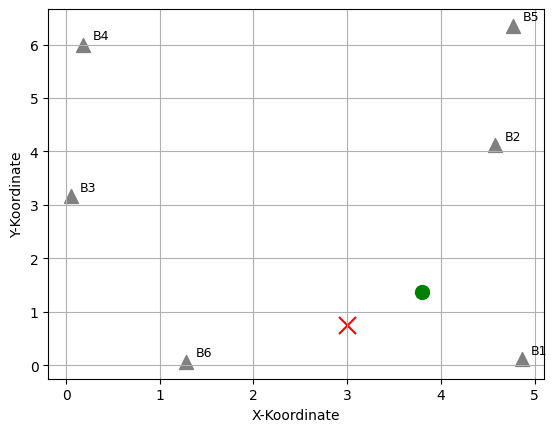

In [ ]:
def WeightedCentroidPositioning3D(data, weightDropoff):
  if len(data) < 3:
      raise ValueError(f"Es sind nur {len(data)} von min. 3 Beacons vorhanden")

  top_beacons = dict(sorted(data.items(), key=lambda item: item[1])[:4]) if do_select_top_beacons else data

  weighted_sum_x = 0.0
  weighted_sum_y = 0.0
  weighted_sum_h = 0.0
  weight_sum = 0.0

  for (x, y, z), dist in top_beacons.items():
    weight = 1.0 / (dist ** weightDropoff)
    weighted_sum_x += x * weight
    weighted_sum_y += y * weight
    weighted_sum_h += z * weight
    weight_sum += weight

  return weighted_sum_x / weight_sum, weighted_sum_y / weight_sum, weighted_sum_h / weight_sum

reference_point = referencePoints[2][:2]

data = {
    (0.05, 3.16, 1.06): 5.838,  # B3
    (4.58, 4.12, 0.36): 4.069,  # B2
    (4.86, 0.11, 0.36): 2.864,  # B1
    (1.28, 0.06, 1.06): 3.367,  # B6
    (4.77, 6.35, 0.56): 4.745   # B5
}
weightDropoff = 3
rtnvl = WeightedCentroidPositioning3D(data, weightDropoff)

print(rtnvl)
fig, ax = plt.subplots()
for beacon, (x, y, z) in beacons.items():
    ax.scatter(x, y, label=beacon, marker='^', color='gray', s=100)
    ax.text(x + 0.1, y + 0.1, beacon, fontsize=9)
rx, ry = reference_point
ax.scatter(rx, ry, color='red', label="Referenzpunkt", marker='x', s=150)
cx, cy, cz = rtnvl
ax.scatter(cx, cy, color='green', label="Berechneter Punkt", s=100)
ax.set_xlabel("X-Koordinate")
ax.set_ylabel("Y-Koordinate")
plt.grid(True)
plt.show()